### meteo.data.gouv.fr SIM2 Quotidien - Lecture d'une décennie en CSV & conversion en fichier PARQUET
Ce script ne gère ni le téléchargement ni la décompression des archives qui doit être effectué préalablement à la main (1h50 de décompression pour chaque décennie)
- data: https://meteo.data.gouv.fr/datasets
- Auteur: L. Duffar

Intérêt : les futurs développements pourront lire les fichiers PARQUET par décennie plus rapidement que les fichier CSV originaux
- 0. Lecture d'un unique fichier CSV Quotidien + enregistrement d'un fichier PARQUET. A FAIRE UNE FOIS POUR TOUTE JUSQU'A L'AVANT DERNIERE DECENNIE DEPUIS 1958
- 1. Lecture de tous les fichiers PARQUET par décennie depuis 1958, et mémorisation des seuls paramètres choisis


#### 0. Lecture d'un unique fichier CSV Quotidien + enregistrement d'un fichier PARQUET
A FAIRE UNE FOIS POUR TOUTE JUSQU'A L'AVANT DERNIERE DECENNIE DEPUIS 1958

L'historique complet commençant en 1958, est découpé en décennies (par exemple 1960-1969). 
- le 1er fichier ne couvre que 19858-08-01 à 1959-12-31
- le dernier fichier (LATEST) le mois précédent et le mois en cours jusqu'à la veille du téléchargement (par exemple 2025-06-01 à 2025-07-19)
- par conséquent l'avant dernier fichier (PREVIOUS) doit être téléchargé en même temps que le fichier LATEST car ils se recouvrent partiellement depuis le début du mois en cours lors du téléchargement. En effet PREVIOUX couvre le début de la décennie en cours jusqu'au dernier jour du mois précédant le téléchargement (par exemple 2020-01-01 à 2025-06-30).

Temps de traitement d'une unique fichier CSV couvrant une décennie :
- lecture du fichier CSV : 20 minutes environ
- enregistrement en fichier PARQUET : 2 minutes environ

In [ ]:
#########################
# Auteur: L. Duffar
# Date: Juillet 2025
#########################
import pandas as pd
import plotly.express as px
import datetime
import requests
import os
import gzip

############### Personalisation
folder_csv = r"X:\1-COMMUN\DIS\Documentation\Hydrologie\Documentation externe\Climat France\Météo-France\meteo.data\REFERENCE\SIM2\Q"

file_csv= "QUOT_SIM2_previous-2020-202506.csv"
file_csv= "QUOT_SIM2_2010_2019.csv"

############### Initialisation
print(datetime.datetime.now().strftime("%Y-%m-%d %H:%M"))

# Définition des Fonctions (téléchargement et de décompression ...)
def convert_to_date(date):
    return pd.to_datetime(str(date), format='%Y%m%d', errors='coerce')

############### Lecture du fichier CSV en pandas

df = pd.read_csv(os.path.join(folder_csv, file_csv), skiprows= 0, header=0, sep=";")
# force numposte en string avec le zéro intial éventuel
df['DATE']= df['DATE'].apply(convert_to_date)

############### Enregistrement du fichier parquet
file_parquet = os.path.join(folder_csv, file_csv.replace(".csv", ".parquet"))
df.to_parquet(file_parquet, index=False)
print(f"Fichier parquet enregistré dans: ", folder_csv)

# Attention, impossible d'afficher df par display(df) dans cette cellule (provoque une erreur d'allocation mémoire). On peut le faire dans une autre cellule

2025-07-20 15:42
Fichier parquet enregistré dans:  X:\1-COMMUN\DIS\Documentation\Hydrologie\Documentation externe\Climat France\Météo-France\meteo.data\REFERENCE\SIM2\Q


#### 0bis. Affichage du dataframe pour contrôle OPTIONNEL

In [6]:
# Affichage du DataFrame (car ne peut être affiché dans la même cellule que la lecture pour cause d'une erreur d'allocation mémoire)
display(df)

TypeError: 'module' object is not callable

#### 1. Lecture de tous les fichiers PARQUET par décennie depuis 1958, et mémorisation des seuls paramètres choisis 
POUR TEST UNIQUEMENT du dataset xarray (raster géographique temporel) contenant tout l'historique des paramètres choisis (IMPOSSIBLE de charger en mémoire TOUS les paramètres pour l'historique COMPLET DEPUIS 1958)

In [8]:
import pandas as pd
import xarray as xr
import rioxarray
import datetime
import os

############### Personalisation
folder_in = r"X:\1-COMMUN\DIS\Documentation\Hydrologie\Documentation externe\Climat France\Météo-France\meteo.data\REFERENCE\SIM2\Q"

parquet_files_list= [
    # "QUOT_SIM2_1958_1959.parquet",
    # "QUOT_SIM2_1960_1969.parquet",
    # "QUOT_SIM2_1970_1979.parquet",
    # "QUOT_SIM2_1980_1989.parquet",
    # "QUOT_SIM2_1990_1999.parquet",
    # "QUOT_SIM2_2000_2009.parquet",
    # "QUOT_SIM2_2010_2019.parquet",
    # "QUOT_SIM2_2010_2019.parquet",
    'QUOT_SIM2_previous-2020-202506.parquet',
    'QUOT_SIM2_latest-20250601-20250719.parquet'
]
param_list = ['SWI_Q']

# rectangle d'intérêt (obligatoire)
lon_min, lat_min, lon_max, lat_max =[4.2, 42.9, 7.75, 44.7]# PACA
x_min, y_min, x_max, y_max =[794580, 1781225, 1077742, 2023337]# PACA en lambert 2 étendu ("EPSG:27572")

# lon_min, lat_min, lon_max, lat_max =[2.92, 43.08, 4.8, 45.0]# Languedoc
# lon_min, lat_min, lon_max, lat_max= [-5.65, 41.0, 10.0, 52.0] # FRANCE métropolitaine avec Corse

############### Initialisation
print(datetime.datetime.now().strftime("%Y-%m-%d %H:%M"))

############### Lecture de l'historique complet pour les paramètres choisis
# agrégation dans le DataFrame df de l'historique complet pour les paramètres choisis
df = pd.DataFrame()
ds= xr.Dataset()
for file in parquet_files_list:
    print(f"Lecture du fichier: {file}")
    file_path = os.path.join(folder_in, file)
    df_temp = pd.read_parquet(file_path)
    # Sélection des paramètres choisis
    df_temp = df_temp[['LAMBX', 'LAMBY', 'DATE'] + param_list]
    # convertir les coordonnées LAMBX et LAMBY en mètres
    df_temp['LAMBX'] = df_temp['LAMBX'] * 100
    df_temp['LAMBY'] = df_temp['LAMBY'] * 100
    # conversion de df_temp en datset xarray, indexé sur 'LAMBX', 'LAMBY', 'DATE' (c'est déjà une colonnet de type date)
    ds_temp= df_temp.set_index(['LAMBX', 'LAMBY', 'DATE']).to_xarray()
    # restriction au rectangle d'intérêt par .sel(LAMBX= .slice(,)) qui est plus concis que ds.where() utilisé dans le code COMEPHORE
    # ds.where((ds.lon >= lon_min) & (ds.lon <= lon_max) &
    #                       (ds.lat >= lat_min) & (ds.lat <= lat_max), drop=True))
    ds_temp = ds_temp.sel(LAMBX= slice(x_min, x_max), LAMBY= slice(y_min, y_max))

    # Concaténation dans le dataset ds
    if ds == xr.Dataset():
        ds = ds_temp
    else:
        ds = xr.merge([ds, ds_temp])

############### Transformation du dataset en données géographiques utilisables avec xarray (rasters géographiques chronologiques)
# inscrit le CRS dans les attributs du dataset
ds = ds.rio.write_crs("IGNF:LAMBE") # a priori équivalent à "EPSG:27572" (lambert 2 étendu)
# Définir explicitement les dimensions spatiales qui sont nommées impérativement 'x' et 'y' comme exigé par la méthode rioxarray.rio.set_spatial_dims()
ds = ds.rename({"LAMBX": "x", "LAMBY": "y"})
ds = ds.rio.set_spatial_dims(x_dim='x', y_dim='y', inplace= True)
# déplacement de la latitude en première dimension spatiale, comme exigé par la fonction rioxarray.rio.reproject()
ds = ds.transpose('DATE', 'y', 'x')
# # reprojection des coordonnées Lambert2 étendues en lat/lon WGS84 (CRS pas défaut des librairies, ce qui facilite le codage)
# ds = ds.rio.reproject("EPSG:4326")
ds

2025-07-20 20:23
Lecture du fichier: QUOT_SIM2_previous-2020-202506.parquet
Lecture du fichier: QUOT_SIM2_latest-20250601-20250719.parquet


<xarray.Dataset> Size: 18MB
Dimensions:      (x: 36, y: 30, DATE: 2027)
Coordinates:
  * x            (x) int64 288B 796000 804000 812000 ... 1060000 1068000 1076000
  * y            (y) int64 240B 1785000 1793000 1801000 ... 2009000 2017000
  * DATE         (DATE) datetime64[ns] 16kB 2020-01-01 2020-01-02 ... 2025-07-19
    spatial_ref  int32 4B 0
Data variables:
    SWI_Q        (DATE, y, x) float64 18MB nan nan nan nan ... nan nan nan nan

#### 2. Carte d'une date pour contrôle EN CHANTIER


20/07/25 20:37


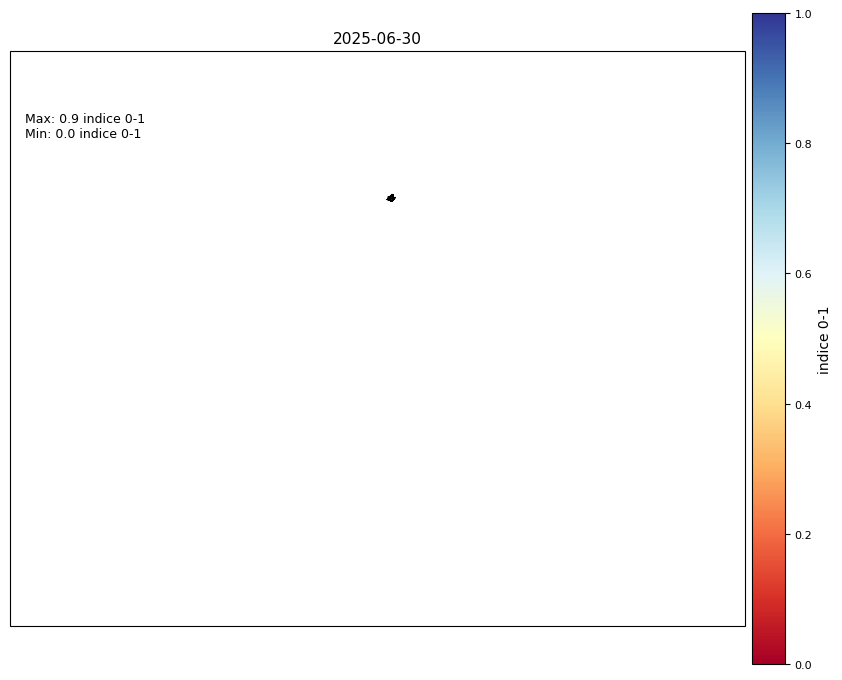

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
import matplotlib.colors
import numpy as np
import geopandas as gpd

############### Personalisation #################################
param= 'SWI_Q'
# param= 'EVAP_Q'
# param= 'T_Q'
# param= 'PRENEI_Q'
# param= 'PRELIQ_Q'
# param= 'ETP_Q'

# DAtes mensuelles avec 01 comme jour
date= '2025-06-30'

# fichier SHP des polygones d'agrégation spatiale (multi-polygones WGS84 inclus dans la zone d'intéret, dans une couche unique)
file_polygones= r"X:\3-PROJ_CONCESSION\2023_11_20-ETU-RESSOURCES BESOINS EAU\1-ETUDE\2- Production\Météo France\Climato SIM2\out\shp\BV_Verdon+Durance+Siagne+Biançon.gpkg"
file_polygones= r"X:\1-COMMUN\DIS\Documentation\Hydrologie\Documentation externe\Climat France\Météo-France\SIM2\PACA\shp\Départements PACA.shp"
# nom de la colonne du fichier SHP qui contient l'IDENTIFIANT de polygone voulu pour les cartes
nom_champ_polygone = 'code'
nom_champ_polygone = 'nom'
# Nouveau nom de COLONE IDENTIFIANT de polygone dans le geodataframe tiré du fichier SHP
# nom_colonne_polygone = 'DEPARTEMENT'
nom_colonne_polygone = 'NOM'

############### Initialisation
print(datetime.datetime.now().strftime('%d/%m/%y %H:%M'))

crs= ccrs.PlateCarree()

# Colormap personalisée pour les précipitations
cmap = plt.get_cmap('YlGnBu')# Obtenez la colormap
colors = cmap(np.arange(cmap.N)) # Convertir la colormap en liste de couleurs
colors[0] = (1, 1, 1, 1)  # # Modifiez la première couleur (RGBA pour blanc)
colors[1] = (1, 1, 1, 1)  # # Modifiez la première couleur (RGBA pour blanc)
# Créez une nouvelle colormap à partir d'une colormap existante transformée en liste de couleurs
cmap_precip = matplotlib.colors.LinearSegmentedColormap.from_list('cmap_precip', colors, cmap.N)

# fonction de modification de colormap en imposant le blanc au début
def modify_colormap(cmap_name):
    """
    Fonction: Modifie en blanc la première couleur d'une colormap et renvoie une nouvelle colormap.
    """
    cmap = plt.get_cmap(cmap_name)  # Obtenez la colormap
    colors = cmap(np.arange(cmap.N))  # Convertissez la colormap en liste de couleurs
    colors[0] = (1, 1, 1, 1)  # Modifie en blanc la première couleur (RGBA)
    colors[1] = (1, 1, 1, 1)  # Modifie en blanc la seconde couleur (RGBA)
    # Créez une nouvelle colormap à partir de la liste de couleurs modifiée
    new_cmap = matplotlib.colors.LinearSegmentedColormap.from_list('new_cmap', colors, cmap.N)
    return new_cmap

# Mdification de certaines colormaps
colormap_names = ['YlGnBu', 'Purples'] # Liste des colormaps à modifier
modified_colormaps = {} # Dictionnaire pour stocker les colormaps modifiées
for cmap_name in colormap_names:
    modified_colormaps[cmap_name] = modify_colormap(cmap_name)
cmpa_precip, cmap_neige = modified_colormaps.values()

# Création d'une colormap divegente personalisée
diverging_temper = matplotlib.colors.LinearSegmentedColormap.from_list('my_gradient', (
    # Edit this gradient at https://eltos.github.io/gradient/#400AAD-3374FF-FFFFFF-FFA012-FF5B4C
    (0.000, (0.165, 0.094, 0.259)),
    (0.250, (0.424, 0.302, 0.725)),
    (0.500, (1.000, 1.000, 1.000)),
    (0.750, (1.000, 0.631, 0.400)),
    (1.000, (0.467, 0.102, 0.075))))

# Préréglages des cartes pour chaque paramètre individuellement (pour l'instant 6)
# pour ajouter des paramètres il faut en plus des réglage ajuster le code pour la pagination (sur la même page ou sur plusieurs)
# clés :    nom colonne     nom en clair                            unité       colormap    [min, centre, max] month   [min, centre, max] year  méthode d'agrégration annuelle
# Bornes min et max pour la colormap annuelle des différents paramètres au pas mensuel et annuel (ci précipitations totales)
param_dict= {'PRENEI_Q': ['Précipitations de neige',             "mm d'eau", cmap_neige, [0, None, 200], [0, None, 1000], 'sum'],
             'PRELIQ_Q': ['Précipitations liquides',             'mm',       cmap_precip, [0, None, 200], [500, None, 1400], 'sum'],
             'T_Q': ['Température moyenne',                      '°C',       diverging_temper, [-5, 0, 40], [-5, 0, 25], 'mean'], 
             'SWI_Q': ['Humidité du sol (Soil Wetness Index)',   'indice 0-1', 'RdYlBu', [0, None, 1], [0, None, 1], 'mean'],
             'ETP_Q': ['ETP',                                    'mm',       'YlOrRd', [0, None, 200], [700, None, 1200], 'sum'],
             'EVAP_Q': ['Evaporation réelle',                    'mm',       'YlOrRd', [0, None, 200], [400, None, 700], 'sum'],
             }

# Gestion de la colormap et des valeurs min et max (et du centre pour T_Q) pour la carte
title= param_dict[param][0]
unite= param_dict[param][1]
# cmap= cmap_precip
cmap= param_dict[param][2]
vmin= param_dict[param][3][0]
vmax= param_dict[param][3][2]
vcenter= param_dict[param][3][1]
norm= None

#========= Lecture du fichier shapefile de polygones
gdf = gpd.read_file(file_polygones)
# renomme la colonne des identifiants de polygones
gdf.rename(columns={ nom_champ_polygone: nom_colonne_polygone}, inplace=True)

############### Carte
# création de la figure
fig = plt.figure(figsize=(10, 10), dpi= 100)
ax = plt.axes(projection= ccrs.PlateCarree()  )  # Projection PlateCarree (lat/lon)

da= ds[param].sel(DATE= date)

# tracer la carte du paramètre
img = da.plot(ax= ax, transform= ccrs.PlateCarree(), cmap= cmap, 
                        add_colorbar= False, vmin= vmin, vmax= vmax, norm= norm)
# Titre 
# nom_mois= pd.to_datetime(month, format='%m').strftime('%B')
ax.set_title(date, fontsize= 11)

# afficher la valeur maximale en haut à gauche
val_max= f'Max: {da.max().values.item():.1f} {unite}' # valeur maximale
val_min= f'Min: {da.min().values.item():.1f} {unite}' # valeur min
ax.annotate(val_max + '\n' + val_min,
                xy=(0.02, 0.85), xycoords='axes fraction', fontsize= 9, ha='left')

# Colorbar : réglage de sa position/taille/graduation & ajout d'un label
if vmax!= None and da.max().values.item() > vmax:# Vérifiez si les données dépassent vmax
    extend = 'max'
else:
    extend = 'neither'
cbar = plt.colorbar(img, ax= ax, fraction= 0.042, pad= 0.01, extend= extend) # extend permet de signaler par un triangle en haut de la colorbar que le maximum est dépassé 
cbar.set_label(unite, size= 10) # Ajouter un label à la colorbar
cbar.ax.tick_params(labelsize= 8) # régler la taille de police des graduations de la colorbar

# Habillage
gdf.plot(ax= ax, facecolor= 'none', edgecolor= 'black', linewidth= 0.7)   # polygones de gdf

# ax.add_feature(cfeature.BORDERS, linestyle= ':')                        # frontières
# ax.add_feature(cfeature.RIVERS)                                         # rivières
# ax.add_feature(cfeature.NaturalEarthFeature('physical', 'rivers_europe', '10m', facecolor='none', edgecolor='lightblue')) # rien de plus sur PACA
# ax.add_feature(cfeature.OCEAN, color= 'lightblue')                      # mer en bleu clair

plt.show()

In [6]:
ds

<xarray.Dataset> Size: 18MB
Dimensions:      (x: 36, y: 30, DATE: 2027)
Coordinates:
  * x            (x) int64 288B 796000 804000 812000 ... 1060000 1068000 1076000
  * y            (y) int64 240B 1785000 1793000 1801000 ... 2009000 2017000
  * DATE         (DATE) datetime64[ns] 16kB 2020-01-01 2020-01-02 ... 2025-07-19
    spatial_ref  int32 4B 0
Data variables:
    SWI_Q        (DATE, y, x) float64 18MB nan nan nan nan ... nan nan nan nan